# Notebook 7: RL-DOHO v2 on gene-expression data (published DO/HO, gain reward, sparse start)

This notebook reruns the gene-expression comparison of Notebook 5 with the three changes below. The datasets, train/test splits, fitness function and evaluation budget are unchanged:

| Dataset | Samples | Features | Classes | Score |
|---|---|---|---|---|
| Colon | 62 | 2,000 | 2 | accuracy |
| ALL/AML | 72 | 7,129 | 2 | accuracy |
| Lung | 203 | 3,312 | 5 | accuracy |
| Glioma | 50 | 4,434 | 4 | accuracy |
| GSE93272 (RA whole blood) | 101 | 5,000 most variable probes | 2 | balanced accuracy |

**Protocol (unchanged):**
- For each seed, a stratified 70/30 split; min-max scaling fitted on the training part.
- Fitness = 0.99 × (1 − 5-fold CV score of KNN, k = 5) + 0.01 × (fraction of genes kept).
- Test score of KNN on the held-out 30%.
- Ten seeds.

**Methods:**
- **Wrappers, all rerun here** with the same evaluation budget and the same sparse initial population: DO, HO, DOHO (the three now as published), RL-DOHO v2, GA, BPSO and BGWO.
- **Filters:** LASSO, mRMR, ReliefF and all features, reused from Notebook 5. They don't depend on any of the changes.

**Runtime:** about 2–4 hours on Colab for everything. Every run is saved as soon as it finishes, so rerunning a cell resumes where it stopped.

### Fixed plan (written before any run of this notebook; all outcomes are reported)

**What changes compared with Notebooks 1–5**
1. **Published DO and HO.**
   - **DO** follows Zhao et al. (2022). Every iteration runs the rising stage (spiral move towards a random point, or the shrink step in "rainy weather"), then the descending stage (Brownian motion around the population mean), then the landing stage (Lévy flight around the elite).
   - **HO** follows Amiri et al. (2024). Phase 1 updates the first half of the population (male and female/immature candidates). Phase 2 is the defence against predators for the second half. Phase 3 is the escape inside shrinking local bounds for all agents, with greedy selection throughout.
   - These replace the simplified three-phase rules used before.
2. **Gain-based reward** for the bandit:
   - *r* = 0.8 · min(1, *g* / *g*_max) + 0.2 · share
   - *g* = fitness gain of the best subset per fitness evaluation spent. Parsimony-only moves give *g* = 0.
   - *g*_max = the largest *g* seen so far in the run.
   - share = the fraction of the arm's candidates that beat the previous population median.
   - The old reward (1 for any accepted change) is kept as an ablation.
3. **Sparse initial subsets** for every wrapper method when *D* > 100. Each agent keeps a log-uniform fraction of the features, between 10 features and 10% of them. Dense initialisation (about 50% of features) is kept as an ablation.

**Budget**
- Budgets are counted in **fitness evaluations**, equal for every method and equal to Notebooks 1–5 (POP × 21 for the rheumatic data, POP × 51 for gene data).
- The published HO evaluates about 3 × POP candidates per iteration, so it runs fewer iterations within the same budget.

**RL-DOHO settings (unchanged, not tuned):** κ = 2 stagnant iterations, tie band ε = 0.001, UCB c = 1, PERTURB flips 1–3 features, 20 tabu redraws.

**Hypotheses and tests (fixed in advance)**
- **H1** RL-DOHO v2 reaches lower fitness than the published DO. Tested with a pooled two-sided sign test over the paired runs, plus per-dataset Wilcoxon signed-rank tests with Holm correction.
- **H2** RL-DOHO v2 against the published HO: no direction predicted, same tests.
- **H3** At 3× the budget, the UCB controller with the gain reward beats random arm choice. Tested with a pooled sign test on fitness.
- **H4** (gene data only) Sparse initialisation lowers RL-DOHO's fitness compared with dense initialisation. Pooled sign test.

All other comparisons (GA, BPSO, BGWO, LASSO, mRMR, ReliefF, all features) are reported with the same per-dataset Friedman + Holm-corrected Wilcoxon tests and pooled sign tests. A difference below 1e-12 counts as a tie.

In [1]:
# ================= 1. SETUP =================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os, time, pickle, warnings, urllib.request, gzip, math
import numpy as np, pandas as pd, scipy.io as sio, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, balanced_accuracy_score, precision_score, recall_score, accuracy_score
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [2]:
# ================= 2. CONFIG =================
ROOT      = '/content/drive/MyDrive' if IN_COLAB else '.'
OUT_DIR   = f"{ROOT}/rl_doho_results_v2_genes"                  # results of this notebook
PREV_DIRS = {"cancer": f"{ROOT}/rl_doho_results_hd",            # Notebook 2: data + fitness caches
             "ra":     f"{ROOT}/rl_doho_results_ra",            # Notebook 3: GSE93272 data + caches
             "nb5":    f"{ROOT}/rl_doho_results_baselines_hd"}  # Notebook 5: filter results + caches
DATA_DIR  = f"{OUT_DIR}/data"
CANCER    = ["colon", "ALLAML", "lung", "GLIOMA"]
DATASETS  = CANCER + ["GSE93272"]
SEEDS     = list(range(10))
POP_SIZE  = 20
BUDGET    = POP_SIZE * 51           # 1,020 fitness evaluations per run, same as Notebooks 2-5
LONG_BUDGET = 3 * BUDGET            # H3: controller test at 3x the budget
INIT      = "sparse"                # change 3 (dense = Notebooks 1-5, kept as an ablation)
KNN_K, CV_FOLDS, TEST_SIZE = 5, 5, 0.3
ALPHA, BETA = 0.99, 0.01
N_TOP_RA  = 5000
SCORING   = {d: "accuracy" for d in CANCER} | {"GSE93272": "balanced_accuracy"}
VERBOSE   = False                   # True prints every iteration of every benchmark run
RUN_ABLATION, RUN_LONG = True, True

# Quick test: set FAST = True to run 1 dataset x 2 seeds before committing to the full run
FAST = False
if FAST: DATASETS, SEEDS = ["colon"], [0, 1]

os.makedirs(DATA_DIR, exist_ok=True)
FAMILY   = ["RL-DOHO", "DO", "HO", "DOHO"]
WRAPPERS = FAMILY + ["GA", "BPSO", "BGWO"]
FILTERS  = ["LASSO", "mRMR", "ReliefF", "All features"]
METHODS  = WRAPPERS + FILTERS
COLORS   = {"DO": "#2a78d6", "HO": "#eb6834", "DOHO": "#1baf7a", "RL-DOHO": "#eda100"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2})
print("Output folder:", OUT_DIR, "| budget per run:", BUDGET, "fitness evaluations")

Output folder: /content/drive/MyDrive/rl_doho_results_v2_genes | budget per run: 1020 fitness evaluations


## 3. Data (identical to Notebook 5)

In [3]:
DATA = {}
URL = "https://raw.githubusercontent.com/jundongl/scikit-feature/master/skfeature/data/{}.mat"
def first_existing(paths, default):
    return next((p for p in paths if os.path.exists(p)), default)
for name in [d for d in DATASETS if d in CANCER]:
    path = first_existing([f"{PREV_DIRS['cancer']}/data/{name}.mat", f"{PREV_DIRS['nb5']}/data/{name}.mat", f"{DATA_DIR}/{name}.mat"], f"{DATA_DIR}/{name}.mat")
    if not os.path.exists(path): urllib.request.urlretrieve(URL.format(name), path)
    d = sio.loadmat(path); DATA[name] = (d["X"].astype(float), d["Y"].ravel())

if "GSE93272" in DATASETS:
    gpath = first_existing([f"{PREV_DIRS['ra']}/data/GSE93272_series_matrix.txt.gz", f"{PREV_DIRS['nb5']}/data/GSE93272_series_matrix.txt.gz",
                            f"{DATA_DIR}/GSE93272_series_matrix.txt.gz"], f"{DATA_DIR}/GSE93272_series_matrix.txt.gz")
    if not os.path.exists(gpath):
        urllib.request.urlretrieve("https://ftp.ncbi.nlm.nih.gov/geo/series/GSE93nnn/GSE93272/matrix/GSE93272_series_matrix.txt.gz", gpath)
    chars = []
    with gzip.open(gpath, "rt") as f:
        for line in f:
            if line.startswith("!Sample_geo_accession"): gsm = [v.strip('"') for v in line.rstrip("\n").split("\t")[1:]]
            elif line.startswith("!Sample_characteristics_ch1"): chars.append([v.strip('"') for v in line.rstrip("\n").split("\t")[1:]])
            elif line.startswith("!series_matrix_table_begin"): break
        expr = pd.read_csv(f, sep="\t", index_col=0, comment="!")
    meta = pd.DataFrame(index=gsm)
    for row in chars:
        keys = {v.split(":", 1)[0].strip() for v in row if ":" in v}
        if len(keys) == 1:
            k = keys.pop(); meta[k] = [v.split(":", 1)[1].strip() if ":" in v else None for v in row]
    meta["individual id"] = meta.get("individual id", pd.Series(meta.index, index=meta.index)).fillna(pd.Series(meta.index, index=meta.index))
    meta_k = meta[~meta["individual id"].duplicated(keep="first")]
    DATA["GSE93272"] = (expr[gsm][meta_k.index].T.values.astype(float), (meta_k["disease state"].str.upper() == "RA").astype(int).values)

pd.DataFrame([{"dataset": n, "samples": X.shape[0], "features": X.shape[1], "classes": len(np.unique(y))} for n, (X, y) in DATA.items()])

,dataset,samples,features,classes
0,colon,62,2000,2
1,ALLAML,72,7129,2
2,lung,203,3312,5
3,GLIOMA,50,4434,4
4,GSE93272,101,54613,2


## 4. Fitness and test evaluation (identical to Notebook 5; earlier fitness caches are reused because the fitness is deterministic)

In [4]:
def mask_str(m): return np.packbits(np.asarray(m, dtype=np.uint8)).tobytes().hex()
NEW_EVALS = {"n": 0}

def use_dataset(name, seed):
    global X_tr, X_te, y_tr, y_te, N_FEATURES, _cache, CV, CUR, SCORE
    X, y = DATA[name]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=seed)
    if name == "GSE93272":
        col_mean = np.nanmean(X_tr, axis=0)
        X_tr = np.where(np.isnan(X_tr), col_mean, X_tr); X_te = np.where(np.isnan(X_te), col_mean, X_te)
        top = np.argsort(X_tr.var(axis=0))[-N_TOP_RA:]; X_tr, X_te = X_tr[:, top], X_te[:, top]
    sc = MinMaxScaler().fit(X_tr); X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)
    N_FEATURES = X_tr.shape[1]
    CV = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=seed); SCORE = SCORING[name]; CUR = (name, seed)
    _cache = {}
    for d in [PREV_DIRS["ra" if name == "GSE93272" else "cancer"], PREV_DIRS["nb5"], OUT_DIR]:
        cf = f"{d}/cache_{name}_s{seed}.pkl"
        if os.path.exists(cf): _cache.update(pickle.load(open(cf, "rb")))

def save_cache_now(): pickle.dump(_cache, open(f"{OUT_DIR}/cache_{CUR[0]}_s{CUR[1]}.pkl", "wb"))

def fitness_function(mask):
    key = mask_str(mask)
    if key in _cache: return _cache[key]["fit"]
    sel = np.flatnonzero(mask)
    if len(sel) == 0:
        _cache[key] = {"fit": 1.0, "acc": 0.0}; return 1.0
    acc = cross_val_score(KNeighborsClassifier(KNN_K), X_tr[:, sel], y_tr, cv=CV, scoring=SCORE).mean()
    f = ALPHA * (1 - acc) + BETA * len(sel) / len(mask)
    _cache[key] = {"fit": f, "acc": acc}; NEW_EVALS["n"] += 1
    return f

def test_metrics(mask):
    sel = np.flatnonzero(mask)
    p = KNeighborsClassifier(KNN_K).fit(X_tr[:, sel], y_tr).predict(X_te[:, sel])
    acc = balanced_accuracy_score(y_te, p) if SCORE == "balanced_accuracy" else accuracy_score(y_te, p)
    return {"test_acc": float(acc), "test_prec": float(precision_score(y_te, p, average="macro", zero_division=0)),
            "test_rec": float(recall_score(y_te, p, average="macro", zero_division=0)), "test_f1": float(f1_score(y_te, p, average="macro"))}
print("Fitness ready.")

Fitness ready.


## 5. Algorithms: published DO and HO, fixed-switch DOHO, RL-DOHO v2, GA, BPSO, BGWO

In [5]:
# ===================== RL-DOHO v2: shared algorithm code =====================
# Every method gets the same number of FITNESS EVALUATIONS (not iterations), because the
# published HO evaluates about 3N candidates per iteration while DO evaluates N.
# Encoding: continuous position x in [LB, UB]^D, feature j selected if sigmoid(x_j) > 0.5 (i.e. x_j > 0).
import math, time
import numpy as np, pandas as pd

LB, UB = -3.0, 3.0

class BudgetExhausted(Exception):
    pass

def binarize(x):
    return (np.asarray(x) > 0).astype(np.int8)          # identical to sigmoid(x) > 0.5

def mkey(mask):
    return np.packbits(np.asarray(mask, dtype=np.uint8)).tobytes()

class Problem:
    """Wraps a (cached, deterministic) fitness function and enforces the evaluation budget."""
    def __init__(self, fitness_fn, D, budget):
        self.fitness_fn, self.D, self.budget, self.calls = fitness_fn, D, budget, 0
    def left(self):
        return self.budget - self.calls
    def f(self, mask):
        if self.calls >= self.budget:
            raise BudgetExhausted
        self.calls += 1
        return float(self.fitness_fn(np.asarray(mask, dtype=np.int8)))
    def fx(self, x):
        return self.f(binarize(x))

# ------------------------------------------------------------------ initialisation
def init_population(rng, N, D, mode="dense"):
    """dense : x ~ U(-1, 1)  -> each feature selected with probability 0.5 (as in Notebooks 1-5).
       sparse: agent i keeps a fraction p_i ~ log-uniform[min(10/D, 0.1), 0.1] of the features
               (used when D > 100: ten features up to 10% of them)."""
    if mode == "dense":
        return rng.uniform(-1, 1, (N, D))
    lo, hi = math.log(min(10.0 / D, 0.1)), math.log(0.1)
    X = np.empty((N, D))
    for i in range(N):
        p = math.exp(rng.uniform(lo, hi))
        sel = rng.random(D) < p
        if not sel.any():
            sel[rng.integers(D)] = True
        X[i] = np.where(sel, rng.uniform(0.1, 1.0, D), -rng.uniform(0.1, 1.0, D))
    return X

def random_position(rng, D, mode):
    return init_population(rng, 1, D, mode)[0]

# ------------------------------------------------------------------ Levy flight (Mantegna)
def levy(rng, shape, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2)
    den = math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2)
    sigma = (num / den) ** (1 / beta)
    u = rng.normal(0, sigma, shape); v = rng.normal(0, 1, shape)
    return u / np.abs(v) ** (1 / beta)

def lognpdf(x):                                          # lognormal pdf, mu = 0, sigma = 1
    x = np.maximum(x, 1e-300)
    return np.exp(-np.log(x) ** 2 / 2) / (x * math.sqrt(2 * math.pi))

# ------------------------------------------------------------------ Dandelion Optimizer (Zhao et al., 2022)
def do_move(rng, X, elite, t, T):
    """One full DO iteration: rising (Eqs. 2-8), descending (Eqs. 10-11), landing (Eqs. 12-14).
    Returns the new population; the caller evaluates it (N evaluations)."""
    N, D = X.shape
    T = max(T, 2); t = min(max(t, 1), T)
    alpha = rng.random() * ((t / T) ** 2 - 2 * t / T + 1)                     # Eq. 4: adaptive step
    a = 1.0 / (T ** 2 - 2 * T + 1); b = -2 * a; c = 1 - a - b
    k = 1 - rng.random() * (c + a * t ** 2 + b * t)                          # Eq. 8 (k with q)
    # --- rising stage
    if rng.standard_normal() < 1.5:                                          # clear weather
        lamb = np.abs(rng.standard_normal((N, D)))
        theta = (2 * rng.random(N) - 1) * math.pi
        r = 1 / np.exp(theta); vx = r * np.cos(theta); vy = r * np.sin(theta)
        Xs = rng.uniform(LB, UB, (N, D))                                     # Eq. 3: random position
        X1 = X + alpha * (vx * vy)[:, None] * lognpdf(lamb) * (Xs - X)       # Eq. 2
    else:                                                                    # rainy weather
        X1 = X * k                                                           # Eq. 7
    X1 = np.clip(X1, LB, UB)
    # --- descending stage (Brownian motion around the population mean)
    beta = rng.standard_normal((N, D))
    Xm = X1.mean(axis=0)                                                     # Eq. 11
    X2 = np.clip(X1 - beta * alpha * (Xm - beta * alpha * X1), LB, UB)      # Eq. 10
    # --- landing stage (Levy flight around the elite)
    step = 0.01 * levy(rng, (N, D))                                          # Eq. 13, s = 0.01, beta = 1.5
    delta = 2 * t / T                                                        # Eq. 14
    X3 = elite + step * alpha * (elite - X2 * delta)                         # Eq. 12
    return np.clip(X3, LB, UB)

# ------------------------------------------------------------------ Hippopotamus Optimization (Amiri et al., 2024)
def ho_iteration(rng, X, F, dominant, t, T, prob, on_eval):
    """One full HO iteration with greedy selection, updating X, F in place.
    Phase 1 (first half): male + female/immature candidates (Eqs. 3-9)      -> 2 evaluations per agent
    Phase 2 (second half): predator + defence candidate (Eqs. 10-16)        -> 2 evaluations per agent
    Phase 3 (all agents): escape within shrinking local bounds (Eqs. 17-19) -> 1 evaluation per agent
    on_eval(x, f) is called for every evaluated candidate that is a hippopotamus position."""
    N, D = X.shape
    half = N // 2
    T = max(T, 1); t = min(max(t, 1), T)
    for i in range(half):
        I1, I2 = rng.integers(1, 3, 2); rho = rng.integers(0, 2, 2)
        g = int(rng.integers(1, N + 1)); grp = rng.choice(N, g, replace=False)
        MG = X[grp].mean(axis=0)
        h = [I2 * rng.random(D) + (1 - rho[0]), 2 * rng.random(D) - 1, rng.random(D),
             I1 * rng.random(D) + (1 - rho[1]), rng.random()]                  # Eq. 4
        h1, h2 = h[rng.integers(5)], h[rng.integers(5)]
        x_m = np.clip(X[i] + rng.random() * (dominant - I1 * X[i]), LB, UB)     # Eq. 3 (male)
        if math.exp(-t / T) > 0.6:                                            # Eq. 5
            x_f = X[i] + h1 * (dominant - I2 * MG)                            # Eq. 6
        elif rng.random() > 0.5:
            x_f = X[i] + h2 * (MG - dominant)                                 # Eq. 7
        else:
            x_f = rng.uniform(LB, UB, D)
        x_f = np.clip(x_f, LB, UB)
        for x in (x_m, x_f):                                                  # Eqs. 8-9: greedy
            f = prob.fx(x); on_eval(x, f)
            if f < F[i]: X[i], F[i] = x, f
    for i in range(half, N):
        pred = rng.uniform(LB, UB, D)                                         # Eq. 10
        f_pred = prob.fx(pred)
        dist = np.abs(pred - X[i]) + 1e-12                                    # Eq. 11
        b_, c_, d_ = rng.uniform(2, 4), rng.uniform(1, 1.5), rng.uniform(2, 3)
        l_ = rng.uniform(-2 * math.pi, 2 * math.pi)                           # 2*pi*g with g in [-1, 1]
        RL = 0.05 * levy(rng, D)                                              # Eq. 13
        if F[i] > f_pred:
            x = RL * pred + (b_ / (c_ - d_ * math.cos(l_))) * (1 / dist)      # Eq. 12, case 1
        else:
            x = RL * pred + (b_ / (c_ - d_ * math.cos(l_))) * (1 / (2 * dist + rng.random(D)))
        x = np.clip(x, LB, UB)
        f = prob.fx(x); on_eval(x, f)
        if f < F[i]: X[i], F[i] = x, f                                        # Eqs. 15-16
    lo, hi = LB / t, UB / t                                                   # Eq. 17: local bounds
    for i in range(N):
        s = [2 * rng.random(D) - 1, rng.random(), rng.standard_normal()][rng.integers(3)]   # Eq. 19
        x = np.clip(X[i] + rng.random() * (lo + s * (hi - lo)), LB, UB)      # Eq. 18
        f = prob.fx(x); on_eval(x, f)
        if f < F[i]: X[i], F[i] = x, f                                        # Eq. 20

# ------------------------------------------------------------------ run bookkeeping
class Tracker:
    """Tracks the best subset found and logs one row per iteration."""
    def __init__(self, name, prob, verbose=False, tie_eps=0.0):
        self.name, self.prob, self.verbose, self.tie_eps = name, prob, verbose, tie_eps
        self.best_f, self.best_x, self.best_m = np.inf, None, None
        self.rows, self.t0 = [], time.time()
    def better(self, f, nf):
        if self.best_m is None: return True
        bf, bn = self.best_f, int(self.best_m.sum())
        e = self.tie_eps
        if e <= 0: return f < bf
        return f < bf - e or (abs(f - bf) <= e and (nf < bn or (nf == bn and f < bf)))
    def offer(self, x, f, mask=None):
        m = binarize(x) if mask is None else mask
        if self.better(f, int(m.sum())):
            self.best_f, self.best_x, self.best_m = f, (None if x is None else np.array(x, float)), m.copy()
            return True
        return False
    def log(self, it, action, F=None, reward=None):
        row = dict(iter=it, evals=self.prob.calls, action=action, best=self.best_f,
                   n_feats=int(self.best_m.sum()), pop_mean=(float(np.mean(F)) if F is not None else np.nan),
                   reward=reward, sec=time.time() - self.t0)
        self.rows.append(row)
        if self.verbose:
            rw = "" if reward is None else f"  r={reward:.3f}"
            print(f"  {self.name:<16} it {it:>3}  evals {self.prob.calls:>5}/{self.prob.budget}  {action:<10}"
                  f" best {self.best_f:.5f}  feats {row['n_feats']:>5}{rw}")
    def result(self):
        return {"mask": self.best_m, "fit": self.best_f, "hist": pd.DataFrame(self.rows)}

def _start(prob, rng, N, init, tr):
    X = init_population(rng, N, prob.D, init)
    F = np.array([prob.fx(x) for x in X])
    for x, f in zip(X, F): tr.offer(x, f)
    tr.log(0, "init", F)
    return X, F

# ------------------------------------------------------------------ DO, HO, DOHO (published update rules)
def run_do(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("DO", prob, verbose)
    T = max(2, (prob.budget - N) // N)
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            X = do_move(rng, X, tr.best_x, t, T)
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            tr.log(t, "DO", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_ho(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("HO", prob, verbose)
    T = max(1, math.ceil((prob.budget - N) / (3 * N)))
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            dom = X[np.argmin(F)].copy()
            ho_iteration(rng, X, F, dom, t, T, prob, tr.offer)
            tr.log(t, "HO", F)
    except BudgetExhausted:
        if tr.rows and tr.rows[-1]["evals"] != prob.calls: tr.log(len(tr.rows), "HO (partial)", F)
    return tr.result()

def run_doho(prob, N, seed, init="dense", verbose=False):
    """Fixed switch: published DO for the first half of the budget, then published HO."""
    rng = np.random.default_rng(seed); tr = Tracker("DOHO", prob, verbose)
    half_budget = prob.budget // 2
    T1 = max(2, (half_budget - N) // N); T2 = max(1, math.ceil((prob.budget - half_budget) / (3 * N)))
    it = 0
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T1 + 1):
            if prob.calls + N > half_budget: break
            X = do_move(rng, X, tr.best_x, t, T1)
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            it += 1; tr.log(it, "DO", F)
        for t in range(1, T2 + 1):
            ho_iteration(rng, X, F, X[np.argmin(F)].copy(), t, T2, prob, tr.offer)
            it += 1; tr.log(it, "HO", F)
    except BudgetExhausted:
        pass
    return tr.result()

# ------------------------------------------------------------------ controllers
class UCB1:
    def __init__(self, n_arms, seed, c=1.0):
        self.rng = np.random.default_rng(seed + 7919); self.c = c
        self.n = np.zeros(n_arms); self.v = np.zeros(n_arms)
    def choose(self):
        untried = np.flatnonzero(self.n == 0)
        if len(untried): return int(self.rng.choice(untried)), "i"
        ucb = self.v + self.c * np.sqrt(2 * np.log(self.n.sum()) / self.n)
        return int(self.rng.choice(np.flatnonzero(np.isclose(ucb, ucb.max())))), "u"
    def update(self, a, r):
        self.n[a] += 1; self.v[a] += (r - self.v[a]) / self.n[a]

class RandomArm(UCB1):
    def choose(self): return int(self.rng.integers(len(self.n))), "r"

class FixedArm(UCB1):
    def __init__(self, n_arms, seed, arm=0):
        super().__init__(n_arms, seed); self.arm = arm
    def choose(self): return self.arm, "f"

ARMS = ("PERTURB", "RESTART", "DO", "HO")

# ------------------------------------------------------------------ RL-DOHO v2
def run_rldoho(prob, N, seed, init="dense", verbose=False, controller="ucb", reward="gain",
               kappa=2, tie_eps=1e-3, k_max=3, tabu_tries=20, intervene=True, name="RL-DOHO"):
    """DO (published) while the best improves; after `kappa` iterations without an accepted improvement,
    a controller picks one arm: PERTURB / RESTART (worse half, tabu) or one published DO / HO iteration.
    reward="gain": 0.8 * min(1, g / g_max) + 0.2 * share, where g = fitness gain of the best per evaluation
                   spent (parsimony-only moves give g = 0) and g_max = largest g seen so far in the run.
    reward="old" : 1 if the best changed, otherwise 0.2 * share (Notebooks 1-5)."""
    rng = np.random.default_rng(seed); D = prob.D
    tr = Tracker(name, prob, verbose, tie_eps=tie_eps)
    ctrl = {"ucb": UCB1, "random": RandomArm}.get(controller)
    ctrl = ctrl(len(ARMS), seed) if ctrl else FixedArm(len(ARMS), seed, arm=ARMS.index(controller))
    T_do = max(2, (prob.budget - N) // N); T_ho = max(1, math.ceil((prob.budget - N) / (3 * N)))
    def sched(T):                     # DO / HO schedules follow the share of the budget already spent
        return min(T, max(1, math.ceil(T * prob.calls / prob.budget)))
    tabu = set(); g_max = 0.0; stag = 0; it = 0
    arm_log = []
    def offer(x, f):
        tabu.add(mkey(binarize(x)))
        return tr.offer(x, f)
    def tabu_draw(make):
        for _ in range(tabu_tries):
            x = np.clip(make(), LB, UB)
            if mkey(binarize(x)) not in tabu: break
        return x
    try:
        X = init_population(rng, N, D, init)
        F = np.array([prob.fx(x) for x in X])
        for x, f in zip(X, F): offer(x, f)
        tr.log(0, "init", F)
        while prob.left() > 0:
            it += 1
            prev_best, prev_feats, prev_med, calls0 = tr.best_f, int(tr.best_m.sum()), float(np.median(F)), prob.calls
            changed_before = (tr.best_f, int(tr.best_m.sum()))
            if not intervene or stag < kappa:
                arm, how = None, None
                X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                F = np.array([prob.fx(x) for x in X])
                for x, f in zip(X, F): offer(x, f)
                moved = np.arange(N)
            else:
                arm, how = ctrl.choose(); a = ARMS[arm]
                if a == "DO":
                    X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                    F = np.array([prob.fx(x) for x in X])
                    for x, f in zip(X, F): offer(x, f)
                    moved = np.arange(N)
                elif a == "HO":
                    F_before = F.copy()
                    ho_iteration(rng, X, F, X[np.argmin(F)].copy(), sched(T_ho), T_ho, prob, offer)
                    moved = np.flatnonzero(F != F_before)
                else:
                    worst = np.argsort(F)[N // 2:]
                    for i in worst:
                        if a == "PERTURB":
                            def make():
                                x = tr.best_x.copy(); k = int(rng.integers(1, k_max + 1))
                                j = rng.choice(D, k, replace=False)
                                x[j] = -np.sign(x[j] + 1e-12) * rng.uniform(0.5, 2.0, k)
                                return x
                        else:
                            make = lambda: random_position(rng, D, init)
                        X[i] = tabu_draw(make)
                        F[i] = prob.fx(X[i]); offer(X[i], F[i])
                    moved = worst
            cost = max(1, prob.calls - calls0)
            changed = (tr.best_f, int(tr.best_m.sum())) != changed_before
            stag = 0 if changed else stag + 1
            g = max(0.0, prev_best - tr.best_f) / cost
            g_max = max(g_max, g)
            if arm is None:
                tr.log(it, "explore", F)
            else:
                share = float(np.mean(F[moved] < prev_med)) if len(moved) else 0.0
                if reward == "gain":
                    r = 0.8 * (min(1.0, g / g_max) if g_max > 0 else 0.0) + 0.2 * share
                else:
                    r = 1.0 if changed else 0.2 * share
                ctrl.update(arm, r)
                arm_log.append((it, ARMS[arm], how, r, prev_best - tr.best_f, cost))
                tr.log(it, f"{ARMS[arm]}({how})", F, reward=r)
    except BudgetExhausted:
        pass
    res = tr.result()
    res["arms"] = pd.DataFrame(arm_log, columns=["iter", "arm", "how", "reward", "gain", "cost"])
    return res

# ------------------------------------------------------------------ GA, BPSO, BGWO (same budget and initial population)
def run_ga(prob, N, seed, init="dense", verbose=False, pc=0.9, tour=3):
    rng = np.random.default_rng(seed); tr = Tracker("GA", prob, verbose); D = prob.D; pm = 1.0 / D
    try:
        X, F = _start(prob, rng, N, init, tr)
        M = binarize(X); it = 0
        while True:
            def pick():
                idx = rng.choice(N, tour, replace=False); return M[idx[np.argmin(F[idx])]]
            new = [tr.best_m.copy()]
            while len(new) < N:
                p1, p2 = pick(), pick()
                if rng.random() < pc:
                    cm = rng.random(D) < 0.5; kids = [np.where(cm, p1, p2), np.where(cm, p2, p1)]
                else:
                    kids = [p1.copy(), p2.copy()]
                for c in kids:
                    c = np.where(rng.random(D) < pm, 1 - c, c).astype(np.int8)
                    if len(new) < N: new.append(c)
            M = np.array(new, dtype=np.int8)
            F = np.empty(N)
            for i in range(N):
                F[i] = prob.f(M[i]); tr.offer(None, F[i], mask=M[i])
            it += 1; tr.log(it, "gen", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_bpso(prob, N, seed, init="dense", verbose=False, c1=2.0, c2=2.0, vmax=6.0):
    rng = np.random.default_rng(seed); tr = Tracker("BPSO", prob, verbose); D = prob.D
    T = max(2, (prob.budget - N) // N)
    try:
        X0, F = _start(prob, rng, N, init, tr)
        X = binarize(X0); V = rng.uniform(-1, 1, (N, D))
        if init == "sparse":                      # start velocities consistent with the sparse masks
            V = np.where(X == 1, rng.uniform(0, 1, (N, D)), rng.uniform(-6, -1, (N, D)))
        pb, pbf = X.copy(), F.copy()
        for t in range(1, T + 1):
            w = 0.9 - 0.5 * t / T
            r1, r2 = rng.random((N, D)), rng.random((N, D))
            V = np.clip(w * V + c1 * r1 * (pb - X) + c2 * r2 * (tr.best_m - X), -vmax, vmax)
            X = (rng.random((N, D)) < 1 / (1 + np.exp(-V))).astype(np.int8)
            F = np.empty(N)
            for i in range(N):
                F[i] = prob.f(X[i]); tr.offer(None, F[i], mask=X[i])
            imp = F < pbf; pb[imp] = X[imp]; pbf[imp] = F[imp]
            tr.log(t, "move", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_bgwo(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("BGWO", prob, verbose); D = prob.D
    T = max(2, (prob.budget - N) // N)
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            a = 2 - 2 * t / T
            leaders = X[np.argsort(F)[:3]].copy()
            new = np.empty_like(X)
            for i in range(N):
                xs = [Lp - (2 * a * rng.random(D) - a) * np.abs(2 * rng.random(D) * Lp - X[i]) for Lp in leaders]
                new[i] = np.clip(np.mean(xs, axis=0), LB, UB)
            X = new
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            tr.log(t, "move", F)
    except BudgetExhausted:
        pass
    return tr.result()

RUNNERS = {"DO": run_do, "HO": run_ho, "DOHO": run_doho, "RL-DOHO": run_rldoho,
           "GA": run_ga, "BPSO": run_bpso, "BGWO": run_bgwo}

print("Algorithms ready:", list(RUNNERS))

Algorithms ready: ['DO', 'HO', 'DOHO', 'RL-DOHO', 'GA', 'BPSO', 'BGWO']


## 6. One detailed run per DO/HO-family method (Colon, seed 0), with every iteration printed

For RL-DOHO, each line shows the action taken: `explore` is a DO iteration while the search is improving, and `ARM(i/u)` is a bandit decision. `i` marks the initial pull of an arm and `u` a UCB choice, followed by its reward `r`.

In [6]:
if "colon" in DATA:
    use_dataset("colon", 0)
    for a in FAMILY:
        print(f"\n{'=' * 100}\n{a}  (colon, seed 0, budget {BUDGET} evaluations, start = {INIT})\n{'=' * 100}")
        res = RUNNERS[a](Problem(fitness_function, N_FEATURES, BUDGET), POP_SIZE, 0, init=INIT, verbose=True)
        print(f"--> {a}: best fitness {res['fit']:.5f}, {int(res['mask'].sum())} genes, test {test_metrics(res['mask'])['test_acc']:.4f}")
    save_cache_now()


RL-DOHO  (colon, seed 0, budget 1020 evaluations, start = sparse)
  RL-DOHO          it   0  evals    20/1020  init       best 0.19064  feats   177
  RL-DOHO          it   1  evals    40/1020  explore    best 0.16588  feats   176
  RL-DOHO          it   2  evals    60/1020  explore    best 0.16588  feats   176
  RL-DOHO          it   3  evals    80/1020  explore    best 0.16588  feats   176
  RL-DOHO          it   4  evals    90/1020  RESTART(i) best 0.16588  feats   176  r=0.000
  RL-DOHO          it   5  evals   110/1020  DO(i)      best 0.16588  feats   176  r=0.200
  RL-DOHO          it   6  evals   170/1020  HO(i)      best 0.16588  feats   176  r=0.000
  RL-DOHO          it   7  evals   180/1020  PERTURB(i) best 0.16588  feats   176  r=0.000
  RL-DOHO          it   8  evals   200/1020  DO(u)      best 0.16588  feats   176  r=0.000
  RL-DOHO          it   9  evals   210/1020  PERTURB(u) best 0.14389  feats   178  r=0.920
  RL-DOHO          it  10  evals   230/1020  explore    bes

## 7. Benchmark: all wrapper methods, every dataset and seed (resumable)

In [7]:
RES_FILE = f"{OUT_DIR}/v2_runs.pkl"
runs = pickle.load(open(RES_FILE, "rb")) if os.path.exists(RES_FILE) else {}
print(f"{len(runs)} runs already saved")

def record(res, prob, t0):
    m = res["mask"]
    return {"fit": float(res["fit"]), "cv": float(_cache[mask_str(m)]["acc"]), "n_feats": int(m.sum()),
            "mask": np.packbits(m), "hist": res["hist"], "arms": res.get("arms"), "calls": prob.calls,
            "sec": time.time() - t0, **test_metrics(m)}

t_start = time.time()
for ds in DATASETS:
    for s in SEEDS:
        todo = [a for a in WRAPPERS if (ds, a, s) not in runs]
        if not todo: continue
        use_dataset(ds, s)
        for a in todo:
            t0 = time.time(); prob = Problem(fitness_function, N_FEATURES, BUDGET)
            runs[(ds, a, s)] = record(RUNNERS[a](prob, POP_SIZE, s, init=INIT, verbose=VERBOSE), prob, t0)
            pickle.dump(runs, open(RES_FILE, "wb"))
        save_cache_now()
        print(f"[{time.strftime('%H:%M:%S')}] {ds} seed {s}: " + "  ".join(f"{a}={runs[(ds, a, s)]['fit']:.4f}" for a in WRAPPERS)
              + f"   elapsed {time.time() - t_start:.0f}s", flush=True)
print("Benchmark complete.")

0 runs already saved
[18:41:40] colon seed 0: RL-DOHO=0.1376  DO=0.1439  HO=0.0913  DOHO=0.1192  GA=0.0472  BPSO=0.1576  BGWO=0.0738   elapsed 25s
[18:42:30] colon seed 1: RL-DOHO=0.0664  DO=0.0693  HO=0.0665  DOHO=0.0912  GA=0.0443  BPSO=0.0918  BGWO=0.0242   elapsed 74s
[18:43:15] colon seed 2: RL-DOHO=0.0938  DO=0.0938  HO=0.0912  DOHO=0.0938  GA=0.0442  BPSO=0.1190  BGWO=0.0952   elapsed 120s
[18:44:02] colon seed 3: RL-DOHO=0.0943  DO=0.2063  HO=0.1184  DOHO=0.1628  GA=0.0718  BPSO=0.1640  BGWO=0.1175   elapsed 167s
[18:44:50] colon seed 4: RL-DOHO=0.1130  DO=0.1599  HO=0.1156  DOHO=0.1131  GA=0.1132  BPSO=0.1599  BGWO=0.1423   elapsed 215s
[18:45:35] colon seed 5: RL-DOHO=0.0443  DO=0.1131  HO=0.0690  DOHO=0.0663  GA=0.0691  BPSO=0.1360  BGWO=0.1172   elapsed 260s
[18:46:22] colon seed 6: RL-DOHO=0.0691  DO=0.0939  HO=0.0468  DOHO=0.0689  GA=0.0472  BPSO=0.0708  BGWO=0.0735   elapsed 307s
[18:47:09] colon seed 7: RL-DOHO=0.0716  DO=0.1129  HO=0.1156  DOHO=0.1431  GA=0.0717  BPSO=

## 8. Filters (reused from Notebook 5) and the Notebook 5 versions of DO/HO/DOHO/RL-DOHO for reference

In [8]:
NB5_FILE = f"{PREV_DIRS['nb5']}/baselines_hd_runs_p20_i50.pkl"
nb5 = pickle.load(open(NB5_FILE, "rb")) if os.path.exists(NB5_FILE) else {}
print(f"Notebook 5 runs found: {len(nb5)}")

# Filters: computed here only if Notebook 5's results are missing (same code as Notebook 5)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
def rank_lasso(X, y, seed):
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-12)
    m = LogisticRegression(penalty="l1", solver="saga", C=0.5, max_iter=3000, random_state=seed).fit(Xs, y)
    return np.argsort(-np.abs(m.coef_).sum(0), kind="stable")
def rank_mrmr(X, y, seed, k_max=2000):
    rel = mutual_info_classif(X, y, random_state=seed); Xs = (X - X.mean(0)) / (X.std(0) + 1e-12); n = len(Xs)
    sel = [int(np.argmax(rel))]; red = np.zeros(X.shape[1])
    for _ in range(min(k_max, X.shape[1]) - 1):
        red += np.abs(Xs.T @ Xs[:, sel[-1]]) / n; score = rel - red / len(sel); score[sel] = -np.inf; sel.append(int(np.argmax(score)))
    rest = [j for j in np.argsort(-rel) if j not in set(sel)]; return np.array(sel + rest)
def rank_relieff(X, y, seed, m=500, k=10):
    rng = np.random.default_rng(seed); Xn = (X - X.min(0)) / (X.max(0) - X.min(0) + 1e-12)
    classes, counts = np.unique(y, return_counts=True); prior = dict(zip(classes, counts / len(y)))
    idx = rng.choice(len(Xn), min(m, len(Xn)), replace=False); W = np.zeros(Xn.shape[1])
    for i in idx:
        d = np.abs(Xn - Xn[i]).sum(1); d[i] = np.inf
        for c in classes:
            cand = np.flatnonzero(y == c); cand = cand[cand != i]
            if len(cand) == 0: continue
            nn = cand[np.argsort(d[cand])[:k]]; diff = np.abs(Xn[nn] - Xn[i]).mean(0)
            W += (-diff if c == y[i] else prior[c] / (1 - prior[y[i]]) * diff) / len(idx)
    return np.argsort(-W, kind="stable")
RANKERS = {"LASSO": rank_lasso, "mRMR": rank_mrmr, "ReliefF": rank_relieff}
def k_grid(D): return sorted({k for k in [5, 10, 20, 50, 100, 200, 500, 1000, 2000, D] if k <= D})
def run_filter(name, seed):
    D = N_FEATURES
    if name == "All features":
        m = np.ones(D, np.int8); return m, fitness_function(m)
    order = RANKERS[name](X_tr, y_tr, seed); best = None
    for k in k_grid(D):
        m = np.zeros(D, np.int8); m[order[:k]] = 1; f = fitness_function(m)
        if best is None or f < best[1] - 1e-12: best = (m, f)
    return best

filt = {}
for ds in DATASETS:
    for s in SEEDS:
        missing = [a for a in FILTERS if (ds, a, s) not in nb5]
        if missing: use_dataset(ds, s)
        for a in FILTERS:
            if (ds, a, s) in nb5:
                r = nb5[(ds, a, s)]; filt[(ds, a, s)] = {k: r[k] for k in ["fit", "cv", "n_feats", "test_acc", "test_prec", "test_rec", "test_f1"]}
            else:
                m, f = run_filter(a, s)
                filt[(ds, a, s)] = {"fit": float(f), "cv": float(_cache[mask_str(m)]["acc"]), "n_feats": int(m.sum()), **test_metrics(m)}
        if missing: save_cache_now()

cols = ["fit", "cv", "n_feats", "test_acc", "test_prec", "test_rec", "test_f1"]
R = pd.DataFrame([{"dataset": k[0], "method": k[1], "seed": k[2], **{c: v[c] for c in cols}} for k, v in {**runs, **filt}.items()
                  if k[0] in DATASETS and k[2] in SEEDS])
V1 = pd.DataFrame([{"dataset": k[0], "method": k[1] + " (v1)", "seed": k[2], **{c: nb5[k][c] for c in cols}} for k in nb5
                   if k[1] in FAMILY and k[0] in DATASETS and k[2] in SEEDS])
print(R.groupby("method").size().to_dict())

Notebook 5 runs found: 550
{'All features': 50, 'BGWO': 50, 'BPSO': 50, 'DO': 50, 'DOHO': 50, 'GA': 50, 'HO': 50, 'LASSO': 50, 'RL-DOHO': 50, 'ReliefF': 50, 'mRMR': 50}


In [9]:
# ================= Statistics helpers =================
from scipy.stats import wilcoxon, friedmanchisquare, binomtest
TIE = 1e-12

def holm(ps):
    ps = np.asarray(ps, float); order = np.argsort(ps); m = len(ps); adj = np.empty(m); run = 0.0
    for i, j in enumerate(order):
        run = max(run, (m - i) * ps[j]); adj[j] = min(1.0, run)
    return adj

def wtl(a, b, higher_better):
    d = np.asarray(a) - np.asarray(b)
    w = int(np.sum(d > TIE) if higher_better else np.sum(d < -TIE)); t = int(np.sum(np.abs(d) <= TIE))
    return w, t, len(d) - w - t

def per_dataset_tests(R, ref, methods, metric, higher_better):
    """Friedman over `methods` (seeds as blocks) and Holm-corrected Wilcoxon of `ref` vs each other method."""
    rows = []
    for ds in R.dataset.unique():
        P = R[R.dataset == ds].pivot_table(index="seed", columns="method", values=metric)[methods].dropna()
        try: fp = friedmanchisquare(*[P[c] for c in methods]).pvalue
        except ValueError: fp = np.nan
        tmp = []
        for c in methods:
            if c == ref: continue
            w, t, l = wtl(P[ref], P[c], higher_better)
            try: p = wilcoxon(P[ref], P[c], zero_method="zsplit").pvalue
            except ValueError: p = 1.0
            tmp.append(dict(dataset=ds, metric=metric, vs=c, W=w, T=t, L=l, mean_diff=float((P[ref] - P[c]).mean()), p=p, friedman_p=fp))
        for r_, h in zip(tmp, holm([x["p"] for x in tmp])): r_["holm_p"] = h; rows.append(r_)
    return pd.DataFrame(rows)

def pooled_sign(R, ref, others, metric, higher_better):
    rows = []
    A = R[R.method == ref].set_index(["dataset", "seed"])[metric]
    for c in others:
        B = R[R.method == c].set_index(["dataset", "seed"])[metric]
        a, b = A.align(B, join="inner")
        w, t, l = wtl(a, b, higher_better)
        p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
        rows.append(dict(metric=metric, vs=c, W=w, T=t, L=l, n=len(a), sign_p=p))
    out = pd.DataFrame(rows); out["holm_p"] = holm(out.sign_p.values) if len(out) else []
    return out

def mean_ranks(R, methods, metric, higher_better):
    X = R[R.method.isin(methods)].copy()
    X["r"] = X.groupby(["dataset", "seed"])[metric].rank(ascending=not higher_better)
    return X.pivot_table(index="method", columns="dataset", values="r").reindex(methods)

def summary_table(R, methods):
    g = R[R.method.isin(methods)].groupby(["dataset", "method"])
    S = g.agg(fit=("fit", "mean"), fit_sd=("fit", "std"), cv=("cv", "mean"), test_acc=("test_acc", "mean"),
              acc_sd=("test_acc", "std"), test_f1=("test_f1", "mean"), n_feats=("n_feats", "mean")).reset_index()
    return S
print("Statistics helpers ready.")

def ablation_report(A, main, variants, label):
    """A: DataFrame dataset, variant, seed, fit, ... ; compares `main` with every other variant."""
    A = A.copy(); A["r"] = A.groupby(["dataset", "seed"]).fit.rank()
    print(f"\n=== {label}: mean per-run rank on fitness (1 = best) ===")
    print(A.pivot_table(index="variant", columns="dataset", values="r").reindex(variants).round(2).assign(
        ALL=A.groupby("variant").r.mean().reindex(variants).round(2)).to_string())
    print(f"\nMean fitness / test accuracy / features:")
    print(A.groupby("variant")[["fit", "test_acc", "n_feats"]].mean().reindex(variants).round(4).to_string())
    P = A.pivot_table(index=["dataset", "seed"], columns="variant", values="fit")
    print(f"\n{main} against each variant (fitness, all runs pooled): W/T/L for {main}, two-sided sign test")
    for v in variants:
        if v == main or v not in P: continue
        a, b = P[main].dropna().align(P[v].dropna(), join="inner")
        w, t, l = wtl(a, b, False); p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
        print(f"  vs {v:<28s} {w:>3}/{t}/{l:<3}  p = {p:.4f}")

Statistics helpers ready.


## 9. Results per dataset

In [10]:
S = summary_table(R, METHODS)
for ds in DATASETS:
    T = S[S.dataset == ds].set_index("method").reindex(METHODS)
    rk = mean_ranks(R[R.dataset == ds], METHODS, "fit", False)[ds]
    ra = mean_ranks(R[R.dataset == ds], METHODS, "test_acc", True)[ds]
    print(f"\n{'=' * 22} {ds} {'=' * 22}")
    print(T.assign(rank_fit=rk, rank_acc=ra)[["fit", "fit_sd", "cv", "test_acc", "acc_sd", "test_f1", "n_feats", "rank_fit", "rank_acc"]].round(4).to_string())


====================== colon ======================
                 fit  fit_sd      cv  test_acc  acc_sd  test_f1  n_feats  rank_fit  rank_acc
method                                                                                      
RL-DOHO       0.0831  0.0291  0.9164    0.7368  0.1081   0.7164     57.8      4.45      6.50
DO            0.1271  0.0405  0.8719    0.7105  0.0868   0.6758     70.4      8.05      7.70
HO            0.0900  0.0236  0.9094    0.7105  0.1116   0.6745     62.8      4.90      7.80
DOHO          0.1109  0.0312  0.8883    0.7105  0.1387   0.6793     63.7      6.60      7.50
GA            0.0625  0.0216  0.9372    0.7632  0.0903   0.7351     62.4      3.00      5.60
BPSO          0.1370  0.0351  0.8628    0.7368  0.0823   0.7060    238.7      9.30      6.40
BGWO          0.1004  0.0363  0.9006    0.7526  0.1024   0.7298    389.5      6.90      5.50
LASSO         0.0279  0.0186  0.9719    0.8211  0.0901   0.8026     15.5      1.10      2.85
mRMR          0.1

## 10. Statistics: per-dataset Friedman + Holm-corrected Wilcoxon (RL-DOHO vs each), pooled sign tests

In [11]:
pd.set_option("display.width", 200)
W = pd.concat([per_dataset_tests(R, "RL-DOHO", METHODS, m, hb) for m, hb in [("fit", False), ("test_acc", True), ("test_f1", True)]])
for (ds, m), g in W.groupby(["dataset", "metric"], sort=False):
    print(f"\n=== {ds} | {m} | Friedman p = {g.friedman_p.iloc[0]:.3g} ===")
    for _, r in g.iterrows():
        print(f"  RL-DOHO vs {r.vs:<13s} W/T/L = {r.W}/{r['T']}/{r.L}   mean diff = {r.mean_diff:+.4f}   p = {r.p:.4f}   Holm p = {r.holm_p:.4f}"
              + ("   SIGNIFICANT" if r.holm_p < 0.05 else ""))
others = [m for m in METHODS if m != "RL-DOHO"]
POOL = pd.concat([pooled_sign(R, "RL-DOHO", others, m, hb) for m, hb in [("fit", False), ("test_acc", True), ("test_f1", True)]])
print("\n=== All datasets pooled: RL-DOHO W/T/L, two-sided sign test, Holm-corrected per metric ===")
print(POOL.round(4).to_string(index=False))
print("\nMean per-run rank on fitness (1 = best):"); print(mean_ranks(R, METHODS, "fit", False).assign(ALL=lambda x: x.mean(1)).round(2).to_string())
print("\nMean per-run rank within the DO/HO family:"); print(mean_ranks(R, FAMILY, "fit", False).assign(ALL=lambda x: x.mean(1)).round(2).to_string())
W.to_csv(f"{OUT_DIR}/v2_stats_per_dataset.csv", index=False); POOL.to_csv(f"{OUT_DIR}/v2_stats_pooled.csv", index=False)
S.to_csv(f"{OUT_DIR}/v2_summary.csv", index=False)


=== colon | fit | Friedman p = 1.35e-11 ===
  RL-DOHO vs DO            W/T/L = 9/0/1   mean diff = -0.0441   p = 0.0039   Holm p = 0.0273   SIGNIFICANT
  RL-DOHO vs HO            W/T/L = 6/0/4   mean diff = -0.0069   p = 0.4316   Holm p = 0.8633
  RL-DOHO vs DOHO          W/T/L = 7/1/2   mean diff = -0.0278   p = 0.0430   Holm p = 0.2578
  RL-DOHO vs GA            W/T/L = 4/0/6   mean diff = +0.0206   p = 0.1934   Holm p = 0.7734
  RL-DOHO vs BPSO          W/T/L = 10/0/0   mean diff = -0.0540   p = 0.0020   Holm p = 0.0195   SIGNIFICANT
  RL-DOHO vs BGWO          W/T/L = 8/0/2   mean diff = -0.0173   p = 0.1934   Holm p = 0.7734
  RL-DOHO vs LASSO         W/T/L = 0/0/10   mean diff = +0.0552   p = 0.0020   Holm p = 0.0195   SIGNIFICANT
  RL-DOHO vs mRMR          W/T/L = 7/0/3   mean diff = -0.0213   p = 0.0840   Holm p = 0.4199
  RL-DOHO vs ReliefF       W/T/L = 4/0/6   mean diff = -0.0098   p = 0.6250   Holm p = 0.8633
  RL-DOHO vs All features  W/T/L = 10/0/0   mean diff = -0.1772  

### 10b. Old (Notebook 5) versus new versions of DO, HO, DOHO and RL-DOHO

In [12]:
if len(V1):
    B = pd.concat([R[R.method.isin(FAMILY)], V1])
    print(B.groupby(["dataset", "method"])[["fit", "test_acc", "n_feats"]].mean().unstack(0).round(4).to_string())
else:
    print("Notebook 5 results not found; skipped.")

                 fit                                  test_acc                                  n_feats                                
dataset       ALLAML  GLIOMA GSE93272   colon    lung   ALLAML  GLIOMA GSE93272   colon    lung  ALLAML  GLIOMA GSE93272  colon    lung
method                                                                                                                                 
DO            0.1051  0.1840   0.0951  0.1271  0.0454   0.8045  0.7533   0.8486  0.7105  0.9443   115.3    69.0    147.7   70.4   217.0
DO (v1)       0.1375  0.2367   0.1276  0.1756  0.0439   0.8182  0.8467   0.8718  0.7158  0.9393  3474.8  2113.6   2438.2  960.1  1583.6
DOHO          0.0793  0.1699   0.0867  0.1109  0.0363   0.8091  0.7867   0.8582  0.7105  0.9377    61.1    84.8    142.2   63.7   225.6
DOHO (v1)     0.1375  0.2339   0.1227  0.1643  0.0432   0.8409  0.8333   0.8673  0.7526  0.9393  3470.1  2114.0   2457.7  952.8  1574.5
HO            0.0595  0.1529   0.0729  0.0900  0

## 11. Ablation at the same budget (every dataset and seed)

In [13]:
ABL_FILE = f"{OUT_DIR}/v2_ablation.pkl"
abl = pickle.load(open(ABL_FILE, "rb")) if os.path.exists(ABL_FILE) else {}
VARIANTS = {   # name -> keyword arguments of run_rldoho (the main RL-DOHO v2 run is reused)
    "RL-DOHO v2 (UCB, gain reward)": None,
    "UCB, old reward":               dict(reward="old"),
    "Random arm":                    dict(controller="random"),
    "PERTURB only":                  dict(controller="PERTURB"),
    "Dense start (as Notebooks 1-5)": dict(init="dense"),
    "No intervention (DO only)":     dict(intervene=False),
}
if RUN_ABLATION:
    for ds in DATASETS:
        for s in SEEDS:
            todo = [v for v, kw in VARIANTS.items() if kw is not None and (ds, v, s) not in abl]
            if not todo: continue
            use_dataset(ds, s)
            for v in todo:
                kw = dict(init=INIT); kw.update(VARIANTS[v])
                t0 = time.time(); prob = Problem(fitness_function, N_FEATURES, BUDGET)
                abl[(ds, v, s)] = record(run_rldoho(prob, POP_SIZE, s, **kw), prob, t0)
                pickle.dump(abl, open(ABL_FILE, "wb"))
            save_cache_now()
            print(f"[{time.strftime('%H:%M:%S')}] ablation {ds} seed {s} done", flush=True)
    A = pd.DataFrame([{"dataset": k[0], "variant": k[1], "seed": k[2], **{c: v[c] for c in cols}} for k, v in abl.items()
                      if k[0] in DATASETS and k[2] in SEEDS] +
                     [{"dataset": k[0], "variant": "RL-DOHO v2 (UCB, gain reward)", "seed": k[2], **{c: v[c] for c in cols}}
                      for k, v in runs.items() if k[1] == "RL-DOHO" and k[0] in DATASETS and k[2] in SEEDS])
    ablation_report(A, "RL-DOHO v2 (UCB, gain reward)", list(VARIANTS), "Ablation, same budget")

[19:30:40] ablation colon seed 0 done
[19:31:01] ablation colon seed 1 done
[19:31:21] ablation colon seed 2 done
[19:31:47] ablation colon seed 3 done
[19:32:09] ablation colon seed 4 done
[19:32:32] ablation colon seed 5 done
[19:32:55] ablation colon seed 6 done
[19:33:20] ablation colon seed 7 done
[19:33:46] ablation colon seed 8 done
[19:34:03] ablation colon seed 9 done
[19:34:33] ablation ALLAML seed 0 done
[19:35:03] ablation ALLAML seed 1 done
[19:35:32] ablation ALLAML seed 2 done
[19:36:02] ablation ALLAML seed 3 done
[19:36:32] ablation ALLAML seed 4 done
[19:37:07] ablation ALLAML seed 5 done
[19:37:39] ablation ALLAML seed 6 done
[19:38:14] ablation ALLAML seed 7 done
[19:38:49] ablation ALLAML seed 8 done
[19:39:17] ablation ALLAML seed 9 done
[19:39:43] ablation lung seed 0 done
[19:40:08] ablation lung seed 1 done
[19:40:39] ablation lung seed 2 done
[19:41:08] ablation lung seed 3 done
[19:41:35] ablation lung seed 4 done
[19:42:02] ablation lung seed 5 done
[19:42:2

## 12. Controller test at 3× the budget (H3)

In [14]:
LONG_FILE = f"{OUT_DIR}/v2_long.pkl"
longr = pickle.load(open(LONG_FILE, "rb")) if os.path.exists(LONG_FILE) else {}
LONG_VARIANTS = {"UCB, gain reward": dict(), "UCB, old reward": dict(reward="old"), "Random arm": dict(controller="random")}
if RUN_LONG:
    for ds in DATASETS:
        for s in SEEDS:
            todo = [v for v in LONG_VARIANTS if (ds, v, s) not in longr]
            if not todo: continue
            use_dataset(ds, s)
            for v in todo:
                kw = dict(init=INIT); kw.update(LONG_VARIANTS[v])
                t0 = time.time(); prob = Problem(fitness_function, N_FEATURES, LONG_BUDGET)
                longr[(ds, v, s)] = record(run_rldoho(prob, POP_SIZE, s, **kw), prob, t0)
                pickle.dump(longr, open(LONG_FILE, "wb"))
            save_cache_now()
            print(f"[{time.strftime('%H:%M:%S')}] long budget {ds} seed {s} done", flush=True)
    L = pd.DataFrame([{"dataset": k[0], "variant": k[1], "seed": k[2], **{c: v[c] for c in cols}} for k, v in longr.items()
                      if k[0] in DATASETS and k[2] in SEEDS])
    ablation_report(L, "UCB, gain reward", list(LONG_VARIANTS), f"Controller test, budget {LONG_BUDGET}")

[19:54:25] long budget colon seed 0 done
[19:55:13] long budget colon seed 1 done
[19:55:56] long budget colon seed 2 done
[19:56:49] long budget colon seed 3 done
[19:57:37] long budget colon seed 4 done
[19:58:34] long budget colon seed 5 done
[19:59:32] long budget colon seed 6 done
[20:00:27] long budget colon seed 7 done
[20:01:18] long budget colon seed 8 done
[20:02:23] long budget colon seed 9 done
[20:03:31] long budget ALLAML seed 0 done
[20:04:36] long budget ALLAML seed 1 done
[20:05:40] long budget ALLAML seed 2 done
[20:06:47] long budget ALLAML seed 3 done
[20:07:54] long budget ALLAML seed 4 done
[20:09:05] long budget ALLAML seed 5 done
[20:10:17] long budget ALLAML seed 6 done
[20:11:24] long budget ALLAML seed 7 done
[20:12:32] long budget ALLAML seed 8 done
[20:13:36] long budget ALLAML seed 9 done
[20:14:41] long budget lung seed 0 done
[20:15:50] long budget lung seed 1 done
[20:17:14] long budget lung seed 2 done
[20:18:28] long budget lung seed 3 done
[20:19:35]

## 13. Hypotheses H1–H4 (fixed in advance): the numbers, whatever they show

In [15]:
def sign_line(a, b, label):
    a, b = a.align(b, join="inner"); w, t, l = wtl(a, b, False); p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
    print(f"{label}: RL-DOHO-side W/T/L = {w}/{t}/{l} over {len(a)} paired runs, two-sided sign test p = {p:.4f}")
F_ = R.pivot_table(index=["dataset", "seed"], columns="method", values="fit")
sign_line(F_["RL-DOHO"], F_["DO"], "H1  RL-DOHO v2 vs published DO (fitness)")
sign_line(F_["RL-DOHO"], F_["HO"], "H2  RL-DOHO v2 vs published HO (fitness)")
if RUN_LONG and len(L):
    P = L.pivot_table(index=["dataset", "seed"], columns="variant", values="fit")
    sign_line(P["UCB, gain reward"], P["Random arm"], f"H3  UCB gain reward vs random arm at budget {LONG_BUDGET}")
if RUN_ABLATION and len(A):
    P = A.pivot_table(index=["dataset", "seed"], columns="variant", values="fit")
    sign_line(P["RL-DOHO v2 (UCB, gain reward)"], P["Dense start (as Notebooks 1-5)"], "H4  sparse vs dense start for RL-DOHO v2")
print("\nPer-dataset Holm-corrected Wilcoxon results for H1/H2 are in section 10.")

H1  RL-DOHO v2 vs published DO (fitness): RL-DOHO-side W/T/L = 44/3/3 over 50 paired runs, two-sided sign test p = 0.0000
H2  RL-DOHO v2 vs published HO (fitness): RL-DOHO-side W/T/L = 23/1/26 over 50 paired runs, two-sided sign test p = 0.7754
H3  UCB gain reward vs random arm at budget 3060: RL-DOHO-side W/T/L = 23/1/26 over 50 paired runs, two-sided sign test p = 0.7754
H4  sparse vs dense start for RL-DOHO v2: RL-DOHO-side W/T/L = 46/0/4 over 50 paired runs, two-sided sign test p = 0.0000

Per-dataset Holm-corrected Wilcoxon results for H1/H2 are in section 10.


## 14. Figures

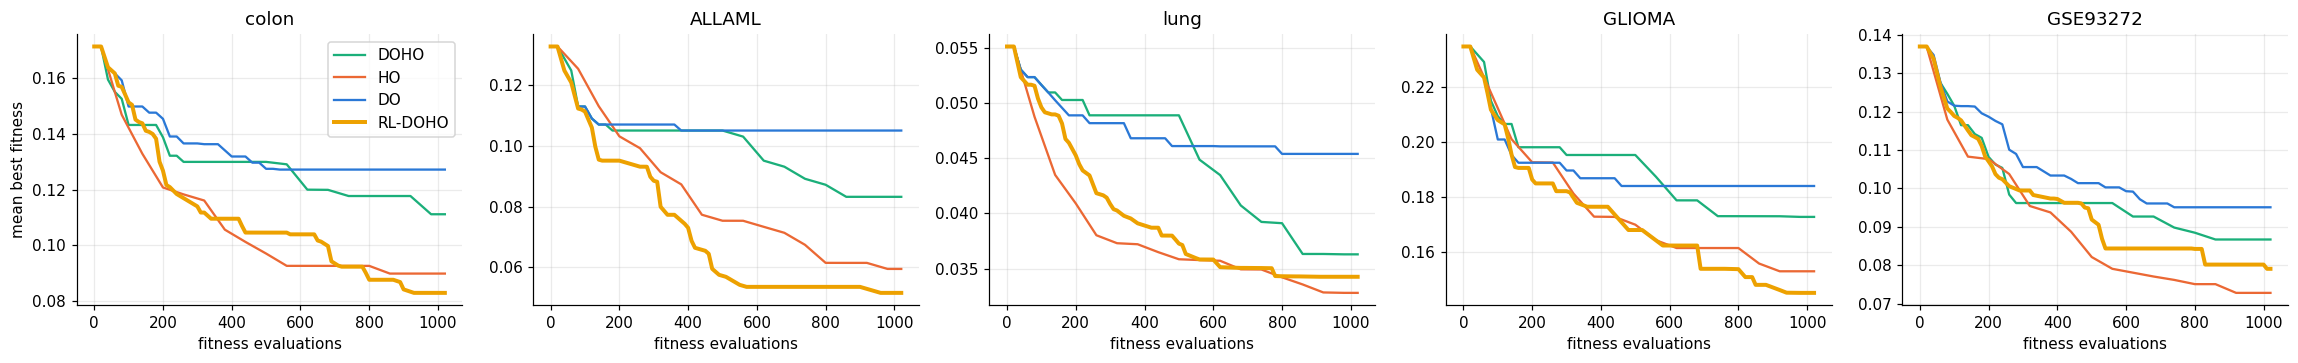

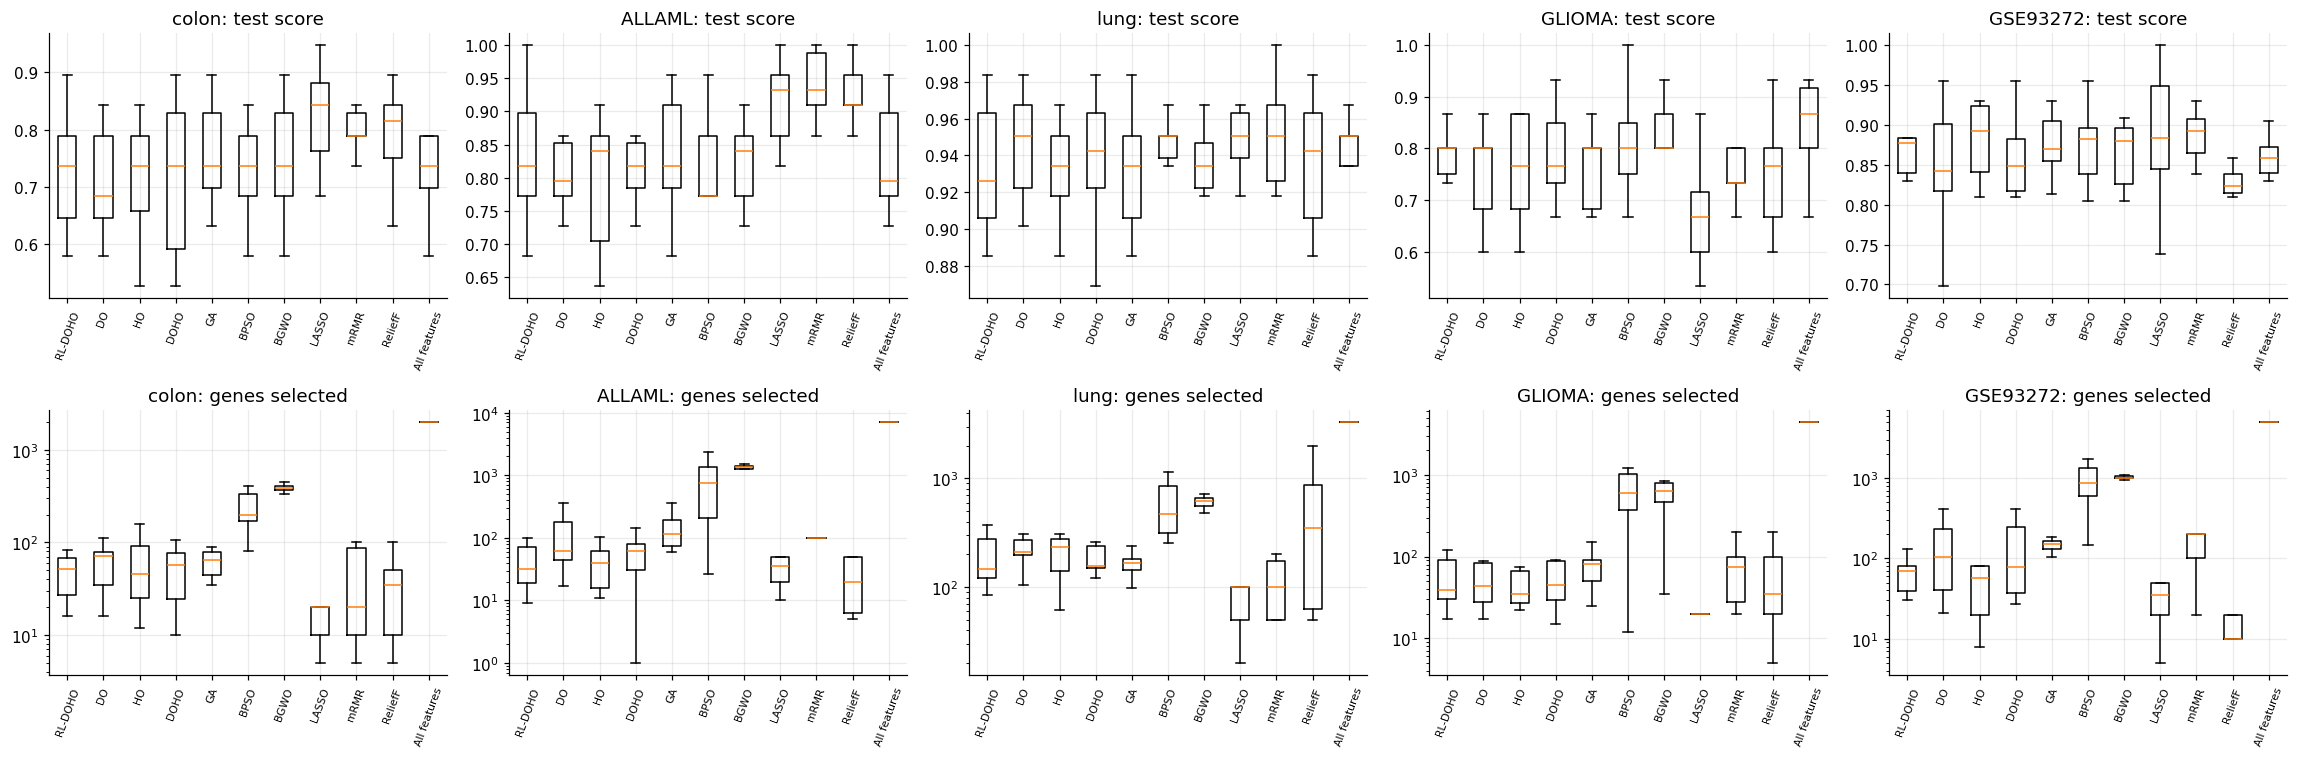

Bandit decisions per run: 27.3
Share of UCB-driven choices per arm:
arm         DO    HO  PERTURB  RESTART
dataset                               
ALLAML    0.27  0.26     0.25     0.22
GLIOMA    0.31  0.24     0.25     0.20
GSE93272  0.28  0.24     0.26     0.22
colon     0.28  0.24     0.28     0.20
lung      0.28  0.26     0.26     0.21
Mean reward and total fitness gain per arm:
         pulls  mean_reward  total_gain
arm                                    
DO         379       0.1603      0.2869
HO         339       0.1173      0.7136
PERTURB    354       0.1211      0.8632
RESTART    293       0.0122      0.0995


In [16]:
# Mean best fitness against fitness evaluations used, DO/HO family, one panel per dataset
grid = np.linspace(0, BUDGET, 103)
def curve(h):
    return np.interp(grid, h["evals"].values, h["best"].values)
fig, ax = plt.subplots(1, len(DATASETS), figsize=(4.2 * len(DATASETS), 3.4), squeeze=False); ax = ax[0]
for k, ds in enumerate(DATASETS):
    for a in FAMILY[::-1]:
        H = [curve(runs[(ds, a, s)]["hist"]) for s in SEEDS if (ds, a, s) in runs]
        if H: ax[k].plot(grid, np.mean(H, 0), color=COLORS[a], lw=2.6 if a == "RL-DOHO" else 1.5, label=a)
    ax[k].set_title(ds); ax[k].set_xlabel("fitness evaluations")
ax[0].set_ylabel("mean best fitness"); ax[0].legend()
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v2_convergence.png", bbox_inches="tight"); plt.show()

# Test accuracy and number of genes, every method
fig, ax = plt.subplots(2, len(DATASETS), figsize=(4.2 * len(DATASETS), 7), squeeze=False)
for k, ds in enumerate(DATASETS):
    for row, (m, lab) in enumerate([("test_acc", "test score"), ("n_feats", "genes selected")]):
        data = [R[(R.dataset == ds) & (R.method == x)][m].values for x in METHODS]
        ax[row, k].boxplot(data, showfliers=False); ax[row, k].set_xticks(range(1, len(METHODS) + 1))
        ax[row, k].set_xticklabels(METHODS, rotation=70, fontsize=7); ax[row, k].set_title(f"{ds}: {lab}")
        if m == "n_feats": ax[row, k].set_yscale("log")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v2_boxplots.png", bbox_inches="tight"); plt.show()

# What the controller chose and what each arm contributed (main RL-DOHO v2 runs)
ARM = pd.concat([runs[k]["arms"].assign(dataset=k[0], seed=k[2]) for k in runs if k[1] == "RL-DOHO" and runs[k]["arms"] is not None
                 and k[0] in DATASETS])
if len(ARM):
    print("Bandit decisions per run:", round(len(ARM) / ARM.groupby(["dataset", "seed"]).ngroups, 1))
    print("Share of UCB-driven choices per arm:"); print(ARM[ARM.how == "u"].groupby("dataset").arm.value_counts(normalize=True).unstack().round(2))
    print("Mean reward and total fitness gain per arm:"); print(ARM.groupby("arm").agg(pulls=("reward", "size"), mean_reward=("reward", "mean"), total_gain=("gain", "sum")).round(4))

## 15. Summary
Everything above is saved in `OUT_DIR`: per-run results (`v2_runs.pkl`, `v2_ablation.pkl`, `v2_long.pkl`), statistics (`v2_stats_*.csv`) and figures.

In [17]:
print("Mean fitness / test score / genes per method and dataset:")
print(S.pivot_table(index="method", columns="dataset", values="fit").reindex(METHODS).round(4).to_string())
print(S.pivot_table(index="method", columns="dataset", values="test_acc").reindex(METHODS).round(4).to_string())
print(S.pivot_table(index="method", columns="dataset", values="n_feats").reindex(METHODS).round(0).to_string())

Mean fitness / test score / genes per method and dataset:
dataset       ALLAML  GLIOMA  GSE93272   colon    lung
method                                                
RL-DOHO       0.0516  0.1450    0.0791  0.0831  0.0343
DO            0.1051  0.1840    0.0951  0.1271  0.0454
HO            0.0595  0.1529    0.0729  0.0900  0.0328
DOHO          0.0793  0.1699    0.0867  0.1109  0.0363
GA            0.0537  0.1105    0.0531  0.0625  0.0284
BPSO          0.1122  0.1966    0.1134  0.1370  0.0366
BGWO          0.0929  0.1879    0.0919  0.1004  0.0339
LASSO         0.0080  0.0085    0.0041  0.0279  0.0190
mRMR          0.0120  0.1190    0.0612  0.1044  0.0235
ReliefF       0.0357  0.1501    0.0926  0.0929  0.0438
All features  0.2120  0.2985    0.1908  0.2602  0.0666
dataset       ALLAML  GLIOMA  GSE93272   colon    lung
method                                                
RL-DOHO       0.8318  0.7867    0.8714  0.7368  0.9328
DO            0.8045  0.7533    0.8486  0.7105  0.9443
HO     